Dataset loaded: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


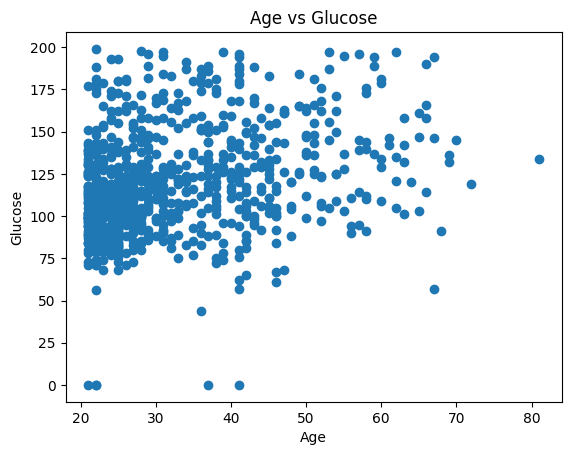

Logistic Regression: 74.68%
Random Forest: 72.08%
XGBoost: 69.48%
                 Model  Accuracy
0  Logistic Regression  0.746753
1        Random Forest  0.720779
2              XGBoost  0.694805


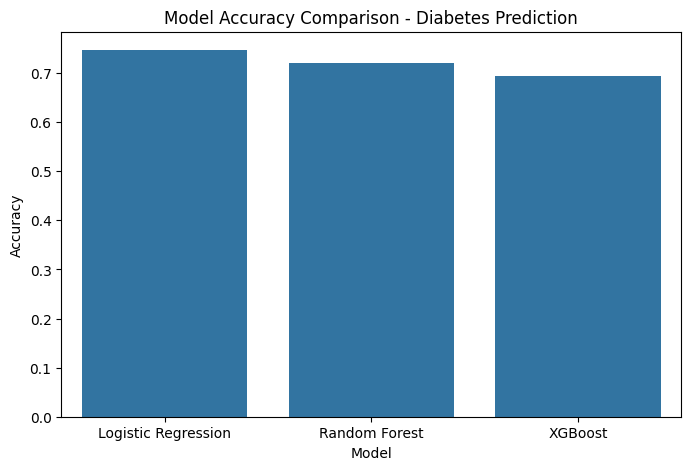

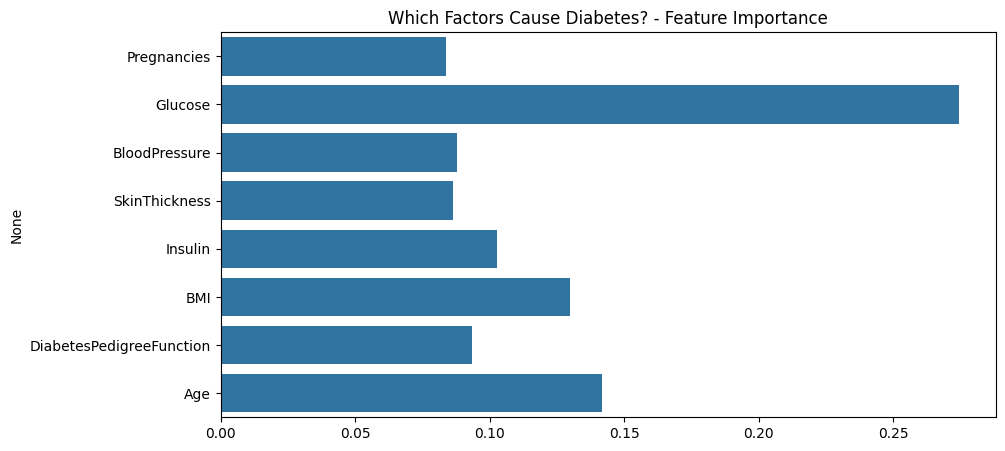

✅ Project Upgraded Successfully! Ready for GKS!


In [15]:
# Medical IT Project - Diabetes Prediction - For Inje University GKS UG Application
# Upgraded Version - 3 Models + Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Direct download - No upload needed!
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)
print("Dataset loaded:", df.shape)
print(df.head())

# Graph 1 - Age vs Glucose
plt.figure()
plt.scatter(df['Age'], df['Glucose'])
plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()

# Prepare data
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# UPGRADE: 3 Models Comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append([name, acc])
    print(f"{name}: {acc*100:.2f}%")

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df)

# Graph 2: Accuracy Comparison
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Model Accuracy Comparison - Diabetes Prediction")
plt.savefig("accuracy_comparison.png")
plt.show()

# Graph 3: Feature Importance
best_model = XGBClassifier(eval_metric='logloss', random_state=42)
best_model.fit(X_train, y_train)
importances = best_model.feature_importances_

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=X.columns)
plt.title("Which Factors Cause Diabetes? - Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

print("✅ Project Upgraded Successfully! Ready for GKS!")